# Training — experiments as data

**Reads:** `data/<DATASET>/split/`, `configs/augment.json` (optional) · **Writes:** `runs/<run_id>/`.

All training logic lives in `thai_char_cnn.train.fit`; this notebook only says *which* runs to
make and reads their results. Each experiment is one row of overrides on a shared `BASE`.

A run is cached under a hash of its full config, seed, `split_id` and `train_version` (a hand-bumped
version of the training code, see `thai_char_cnn.train`). Rerunning the notebook loads finished runs
instead of retraining them, so adding a row trains only that row. Adding a model or a new config key
leaves existing runs alone; a change to what an existing config produces bumps `TRAIN_VERSION`, and
`VERIFY=1` catches a forgotten bump.

Switches, all off by default:

| env var | effect |
| --- | --- |
| `RETRAIN=1` | ignore the cache and retrain every row (overwrites its run) |
| `VERIFY=1` | §5 retrains the first run into a scratch folder and checks it matches the cached one |
| `EPOCHS=n` | smoke run with `n` epochs (a separate run, since epochs are part of the hash) |
| `FREEZE=1` | §7 copies the submission candidates to `models/` (checked into git) for `05_submit` |

### What the score is, and isn't

- The score is **val macro-F1 over validated classes**: per-class F1 averaged with equal weight, over
  the classes `03_split` could give enough val images. Accuracy is shown too, but with this
  imbalance it mostly reflects the ten biggest classes.
- Val is chosen **by writer**, so it measures unseen handwriting. It is also used for early
  stopping and for choosing between experiments, so it is optimistic. The instructor's hidden test
  set is the real test, and nothing here is called "test".
- Classes flagged *not validated* are trained on, but nothing measures them. They are listed below.

## 1 · Setup and data check

**What:** load the current split and check it passed its own self-checks, then show what the
training pipeline actually feeds the model, augmentation included.

**Why the montage is here:** the augmentation preview (`05_augment_preview.py`) is deferred. Until
it exists, this is the only look at what augmentation does to the glyphs. Augmentation is tiered
per class (`thai_char_cnn.augment.TIER_GROUPS`): robust glyphs get the full range, hook/loop pairs,
ascender/descender letters, marks and the า/ๅ pair get progressively less. Each row's label shows
the character and its tiers.

In [1]:
import json
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib import font_manager
from matplotlib.colors import LogNorm
from PIL import Image

from thai_char_cnn.augment import build_train_transform, load_augment_config
from thai_char_cnn.data import SplitData
from thai_char_cnn.metrics import top_confused
from thai_char_cnn.paths import CONFIGS, FONT, RAW, ROOT, RUNS, SPLIT_DIR
from thai_char_cnn.preprocess import letterbox
from thai_char_cnn.submit import MODELS, freeze
from thai_char_cnn.train import (
    DEFAULT_CONFIG,
    TRAIN_VERSION,
    fit,
    load_runs,
    resolve_config,
)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
font_manager.fontManager.addfont(str(FONT))
THAI = font_manager.FontProperties(fname=str(FONT), size=16)

split_run = json.loads((SPLIT_DIR / "run.json").read_text())
SPLIT_ID = split_run["split_id"]
failed = [k for k, v in split_run["checks"].items() if v != "PASS"]
assert not failed, f"03_split self-checks failed: {failed}"

aug_path = CONFIGS / "augment.json"
AUG = load_augment_config(aug_path)
print(f"split_id     : {SPLIT_ID}   ({split_run['generated_at']})")
print(f"augmentation : {'configs/augment.json' if aug_path.exists() else 'defaults (no configs/augment.json yet)'}")
print(f"               overrides: profiles={AUG.profiles or '{}'}, tiers={AUG.tiers or '{}'}")
print(f"device       : {'cuda — ' + torch.cuda.get_device_name() if torch.cuda.is_available() else 'cpu'}")

data = SplitData(DEFAULT_CONFIG["img_size"], DEFAULT_CONFIG["preprocess"])
print(f"\ntrain images : {len(data.idx['train']):,}")
print(f"val images   : {len(data.idx['val']):,}")
print(f"pixel mean/std (train only): {data.pixel_mean:.4f} / {data.pixel_std:.4f}")
classes = data.classes
print(f"classes      : {classes.status.value_counts().to_dict()}")
print(f"not validated: {', '.join(f'{r.folder} {r.character}' for r in classes[classes.status == 'not_validated'].itertuples())}")
print(f"weak (val<5) : {', '.join(f'{r.folder} {r.character}' for r in classes[classes.status == 'weak'].itertuples())}")

split_id     : d0a0d7ada85a   (2026-09-25T03:45:34+00:00)
augmentation : configs/augment.json
               overrides: profiles={}, tiers={'จ': [4], 'ด': [4], 'ต': [4], 'ว': [5], 'า': [5], 'ใ': [5]}
device       : cuda — NVIDIA GeForce RTX 3060



train images : 48,400
val images   : 11,996
pixel mean/std (train only): 0.5647 / 0.4445
classes      : {'validated': 56, 'not_validated': 11, 'weak': 5}
not validated: 163 ฃ, 177 ฑ, 196 ฤ, 204 ฬ, 206 ฮ, 214 ึ, 244 ๔, 245 ๕, 246 ๖, 247 ๗, 249 ๙
weak (val<5) : 189 ฝ, 207 ฯ, 225 แ, 234 ๊, 248 ๘


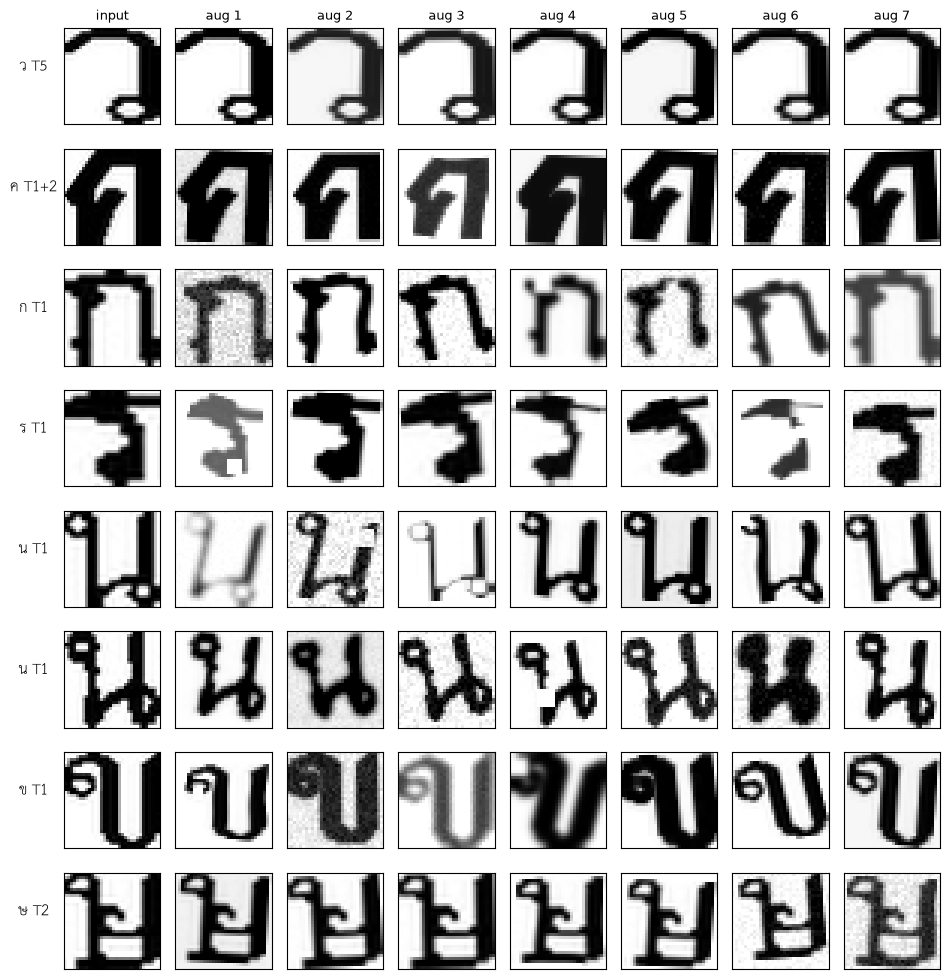

In [2]:
# first column: the model input as-is; the rest: independent draws of the train transform
N_ROWS, N_DRAWS = 8, 7
torch.manual_seed(0)
rng = np.random.default_rng(0)
pick = rng.choice(data.idx["train"], N_ROWS, replace=False)
tf = build_train_transform(AUG, classes.character.tolist())
TIERS = AUG.resolved_tiers()
fig, ax = plt.subplots(N_ROWS, N_DRAWS + 1, figsize=(1.2 * (N_DRAWS + 1), 1.25 * N_ROWS))
for r, j in enumerate(pick):
    px = data.pixels[j]
    for c in range(N_DRAWS + 1):
        img = px if c == 0 else tf(px, int(data.y[j]))
        ax[r, c].imshow(img[0], cmap="gray", vmin=0, vmax=255)
        ax[r, c].set_xticks([])
        ax[r, c].set_yticks([])
    ch = classes.character.iloc[int(data.y[j])]
    ax[r, 0].set_ylabel(f"{ch} T{'+'.join(map(str, TIERS[ch]))}", fontproperties=THAI, rotation=0, labelpad=22)
ax[0, 0].set_title("input", fontsize=9)
for c in range(1, N_DRAWS + 1):
    ax[0, c].set_title(f"aug {c}", fontsize=9)
plt.tight_layout()
plt.show()

## 2 · Experiment table

`BASE` is shared by every run; `EXPERIMENTS` maps a name to the overrides that make it different.
Anything not listed takes `thai_char_cnn.train.DEFAULT_CONFIG`.

The default input is square `stretch`, which beat aspect-preserving `letterbox` on every seed, before
and after the data audit. `stretch+augment` adds tiered augmentation (`augment=True`, see §1) and is
the recommended model; `stretch` stays as its no-augmentation control, since the two are still tied.

`resnet18@64` and `resnet18-pretrained@64` ask whether a bigger backbone helps, and separately
whether ImageNet weights do. Both use torchvision's ResNet-18 with a one-channel stem on 64 px
input (its stem downsamples 4x, too much for 32 px) and tiered augmentation, at `lr=1e-3` so
fine-tuning doesn't overwrite the pretrained features. They differ only in `pretrained`: random
init vs the `IMAGENET1K_V1` weights, with the RGB stem kernel summed to one channel. Compare both
with `stretch+augment`. Neither beats it.

Rows are kept only while they answer an open question. Retired experiments, and the results that
retired them, are recorded in `reports/training-decisions.md`; the final comparison across all of
them is `reports/final-report.md`. Each configuration uses three seeds because small single-seed
gaps are not decision-quality evidence.

`EPOCHS`, `RETRAIN` and `VERIFY` come from the environment (see the top of the notebook), so a
command-line run can set them without editing the notebook.

In [3]:
BASE = dict(epochs=int(os.environ.get("EPOCHS", DEFAULT_CONFIG["epochs"])))
SEEDS = [42, 137, 271]
RETRAIN = os.environ.get("RETRAIN") == "1"
VERIFY = os.environ.get("VERIFY") == "1"

# ResNet-18 at 64 px: identical recipe, so the two rows differ only in their initial weights
RESNET = dict(model="resnet18", img_size=64, augment=True, lr=1e-3)

EXPERIMENTS = {
    "stretch": {},
    "stretch+augment": dict(augment=True),
    "resnet18@64": RESNET,
    "resnet18-pretrained@64": RESNET | dict(pretrained="IMAGENET1K_V1"),
}

table = pd.DataFrame({name: DEFAULT_CONFIG | BASE | ov for name, ov in EXPERIMENTS.items()}).T
varying = [c for c in table.columns if table[c].astype(str).nunique() > 1]
print(f"shared      : {({k: v for k, v in (DEFAULT_CONFIG | BASE).items() if k not in varying})}")
print(f"seeds       : {SEEDS}")
print(f"train ver.  : {TRAIN_VERSION}")
print(f"RETRAIN={RETRAIN}  VERIFY={VERIFY}")
table[varying] if varying else table[[]].assign(overrides="none — baseline only")

shared      : {'pretrained': None, 'freeze_through': None, 'mlp_hidden': None, 'width': 32, 'dropout': 0.3, 'use_geometry': False, 'preprocess': 'stretch', 'sampler': 'none', 'epochs': 40, 'batch_size': 256, 'weight_decay': 0.0005, 'warmup_epochs': 1, 'label_smoothing': 0.0, 'patience': 8, 'seed': 42, 'amp': True}
seeds       : [42, 137, 271]
train ver.  : 1
RETRAIN=False  VERIFY=False


,model,img_size,augment,lr
stretch,small_cnn,32,False,0.003
stretch+augment,small_cnn,32,True,0.003
resnet18@64,resnet18,64,True,0.001
resnet18-pretrained@64,resnet18,64,True,0.001


## 3 · Train (or load)

One loop. A finished run is loaded from `runs/`; anything new is trained, and with `RETRAIN=1`
everything is. On the RTX 3060 a baseline epoch takes about two seconds, a ResNet-18 epoch at 64 px about
nine (augmentation on the CPU is the bottleneck), so a ResNet run takes up to about 6 minutes.

In [4]:
RUN_DIRS = {}
for name, overrides in EXPERIMENTS.items():
    for seed in SEEDS:
        RUN_DIRS.setdefault(name, []).append(fit(BASE | overrides | dict(name=name, seed=seed),
                                                 force=RETRAIN))

[stretch] cached -> /mnt/srv/home/whats/cnn/repo/runs/28d32bd7713a
[stretch] cached -> /mnt/srv/home/whats/cnn/repo/runs/fc42a6285144
[stretch] cached -> /mnt/srv/home/whats/cnn/repo/runs/c324b6b57c75
[stretch+augment] cached -> /mnt/srv/home/whats/cnn/repo/runs/1e94eb59c37d
[stretch+augment] cached -> /mnt/srv/home/whats/cnn/repo/runs/c80f69cf5af9
[stretch+augment] cached -> /mnt/srv/home/whats/cnn/repo/runs/f4747ccb4bb3
[resnet18@64] cached -> /mnt/srv/home/whats/cnn/repo/runs/d12f65132771
[resnet18@64] cached -> /mnt/srv/home/whats/cnn/repo/runs/95033e7c4f6d
[resnet18@64] cached -> /mnt/srv/home/whats/cnn/repo/runs/bad6a5679718
[resnet18-pretrained@64] cached -> /mnt/srv/home/whats/cnn/repo/runs/583115bf51ce
[resnet18-pretrained@64] cached -> /mnt/srv/home/whats/cnn/repo/runs/a23d54ff1e27
[resnet18-pretrained@64] cached -> /mnt/srv/home/whats/cnn/repo/runs/243eb9a86def


## 4 · Leaderboard

Ranked by val macro-F1 over validated classes, mean ± standard deviation across seeds. Only runs in
the current experiment table are ranked, and those are by construction on the current `split_id`
and `train_version`. Other runs on disk are listed below as a record, not compared, with the reason: a
different split means a different val set, and different code means a different pipeline.

In [5]:
runs = load_runs()
current_ids = {p.name for dirs in RUN_DIRS.values() for p in dirs}
cur = runs[runs.run_id.isin(current_ids)].copy()
name_of = {p.name: n for n, dirs in RUN_DIRS.items() for p in dirs}
cur["experiment"] = cur.run_id.map(name_of)

board = (cur.groupby("experiment")
         .agg(seeds=("seed", "size"), macro_f1=("val_macro_f1", "mean"), macro_f1_sd=("val_macro_f1", "std"),
              macro_f1_all=("val_macro_f1_all", "mean"), val_acc=("val_acc", "mean"),
              best_epoch=("best_epoch", "mean"), trainable=("n_trainable", "first"), minutes=("train_time_s", lambda s: s.sum() / 60))
         .sort_values("macro_f1", ascending=False).round(4))
print(f"split {SPLIT_ID} · headline = macro-F1 over {int((classes.status == 'validated').sum())} validated classes\n")
display(board)

other = runs[~runs.run_id.isin(current_ids)]
if len(other):
    other = other.assign(reason=np.select(
        [other.split_id != SPLIT_ID, other["train_version"] != resolve_config({})["train_version"]],
        ["older split", "older code"], "not in the experiment table"))
    print(f"\nnot ranked: {len(other)} other run(s) on disk")
    display(other[["run_id", "name", "reason", "split_id", "train_version", "cfg.code_hash", "cfg.epochs", "seed", "val_macro_f1"]])

split d0a0d7ada85a · headline = macro-F1 over 56 validated classes



,seeds,macro_f1,macro_f1_sd,macro_f1_all,val_acc,best_epoch,trainable,minutes
experiment,,,,,,,,
stretch+augment,3,0.9894,0.0013,0.9870,0.9902,22.6667,NaN,5.5033
stretch,3,0.9889,0.0020,0.9886,0.9904,21.6667,NaN,2.9917
resnet18@64,3,0.9884,0.0029,0.9883,0.9883,15.0000,NaN,9.8667
resnet18-pretrained@64,3,0.9872,0.0004,0.9850,0.9888,17.6667,11207176.0,11.1900



not ranked: 131 other run(s) on disk


,run_id,name,reason,split_id,train_version,cfg.code_hash,cfg.epochs,seed,val_macro_f1
0,01cbfd119b68,letterbox-cleaned,older code,d0a0d7ada85a,,b41693cfacf2,40,137,0.984108
1,04a3a9094f09,stretch+augment-uniform,not in the experiment table,d0a0d7ada85a,1.p2,fdba95a2a0a6,40,271,0.983987
2,058bab03c7cb,resnet18-pretrained@64,older code,d0a0d7ada85a,,f25285474a8f,40,137,0.987525
3,05b212628308,baseline,older split,49bb16a21863,,NaN,40,42,0.973850
4,06e4c16588c5,stretch+augment-ramp,not in the experiment table,d0a0d7ada85a,1.p2,a8910995d481,40,137,0.987850
...,...,...,...,...,...,...,...,...,...
136,f2fcf48bba55,letterbox+geometry,older split,49bb16a21863,,b41693cfacf2,40,42,0.977198
138,f4eaddcaf8c9,letterbox+geometry,not in the experiment table,d0a0d7ada85a,1.p2,fdba95a2a0a6,40,42,0.986786
139,fa72fa08ea40,resnet18-pretrained-frozen@64,not in the experiment table,d0a0d7ada85a,1.p2,ac396e469e8b,40,42,0.854301
140,faa83bbdc479,letterbox+augment-uniform,older split,49bb16a21863,,b41693cfacf2,40,271,0.971060


## 5 · Reproducibility check (`VERIFY=1`)

**What:** retrain the first run of the first experiment from scratch into a scratch folder and
compare it with the cached run: metrics, per-epoch history, every val prediction, and the weights.

**Why:** the cache is only trustworthy if training is deterministic. Seeds, cuDNN's deterministic
mode and seeded data-loader workers are meant to make it so; this measures whether they do.

**How to read it:**

- **exact** — identical weights. The cache is a faithful stand-in for retraining.
- **drift** — macro-F1 within 0.005. Expected after a change of GPU, driver, PyTorch/CUDA version
  or `num_workers`, which reorder floating-point work. Not a bug; worth a note.
- **mismatch** — a larger gap. Something the run hash doesn't capture changed; investigate before
  trusting any cached number.

It costs one extra training run, so it's off unless asked for.

In [6]:
DRIFT_TOL = 0.005
if not VERIFY:
    print("skipped (set VERIFY=1 to retrain and compare)")
else:
    ref_name = next(iter(EXPERIMENTS))
    ref = RUN_DIRS[ref_name][0]
    ref_cfg = BASE | EXPERIMENTS[ref_name] | dict(name=ref_name, seed=SEEDS[0])
    with tempfile.TemporaryDirectory() as tmp:
        new = fit(ref_cfg, data=data, runs_dir=Path(tmp), verbose=False)
        ma, mb = (json.loads((d / "metrics.json").read_text()) for d in (ref, new))
        ha, hb = (pd.read_csv(d / "history.csv") for d in (ref, new))
        pa, pb = (pd.read_csv(d / "val_predictions.csv") for d in (ref, new))
        sa, sb = (torch.load(d / "model.pt", weights_only=False)["state_dict"] for d in (ref, new))
    same_id = new.name == ref.name
    dw = max(float((sa[k].float() - sb[k].float()).abs().max()) for k in sa)
    df1 = abs(ma["val_macro_f1"] - mb["val_macro_f1"])
    hcols = ["train_loss", "val_loss", "val_macro_f1"]
    verdict = ("exact" if same_id and dw == 0 else "drift" if same_id and df1 <= DRIFT_TOL else "mismatch")

    print(f"retrained {ref_name!r} (run {ref.name}) from scratch in {mb['train_time_s']:.0f}s")
    print(f"  same run id          : {same_id}")
    print(f"  val macro-F1         : cached {ma['val_macro_f1']:.6f}  retrained {mb['val_macro_f1']:.6f}")
    print(f"  best epoch           : cached {ma['best_epoch']}  retrained {mb['best_epoch']}")
    print(f"  history max |diff|   : {float((ha[hcols] - hb[hcols]).abs().max().max()) if len(ha) == len(hb) else 'length differs'}")
    print(f"  val predictions diff : {int((pa.pred_idx != pb.pred_idx).sum())} of {len(pa):,}")
    print(f"  weights max |diff|   : {dw}")
    print(f"\nverdict: {verdict.upper()}")
    assert verdict != "mismatch", "retraining does not reproduce the cached run"

skipped (set VERIFY=1 to retrain and compare)


## 6 · Best model

Everything below reads one run: the top experiment of the §4 leaderboard (highest mean val
macro-F1), and within it the seed with the highest val macro-F1. Set `FOCUS=<experiment>` in the
environment to look at another experiment instead; nothing else needs editing.

Picking the seed on val makes its score a little optimistic on top of the val bias noted at the top.
Quote the experiment's mean ± sd from §4 as the result; this run is the model the figures describe.

Every figure is shown here and also written to `reports/figures/<name>.png` (200 dpi) for the
report, next to `selected_model.json`, which records which run produced them. Rerunning the notebook
overwrites them, so the report's figures always match the current leaderboard.

selected : stretch+augment  run c80f69cf5af9  seed 137  split d0a0d7ada85a
  experiment val macro-F1        : 0.9894 ± 0.0013 over 3 seeds
  val macro-F1 (validated classes) : 0.9907
  val macro-F1 (all with val)      : 0.9882
  val accuracy                     : 0.9892
  best epoch 17 of 25 run, 93s, 296,168 params


,run_id,seed,val_macro_f1,val_acc,best_epoch
117,c80f69cf5af9,137,0.9907,0.9892,17
15,1e94eb59c37d,42,0.9893,0.9917,35
137,f4747ccb4bb3,271,0.9881,0.9897,16


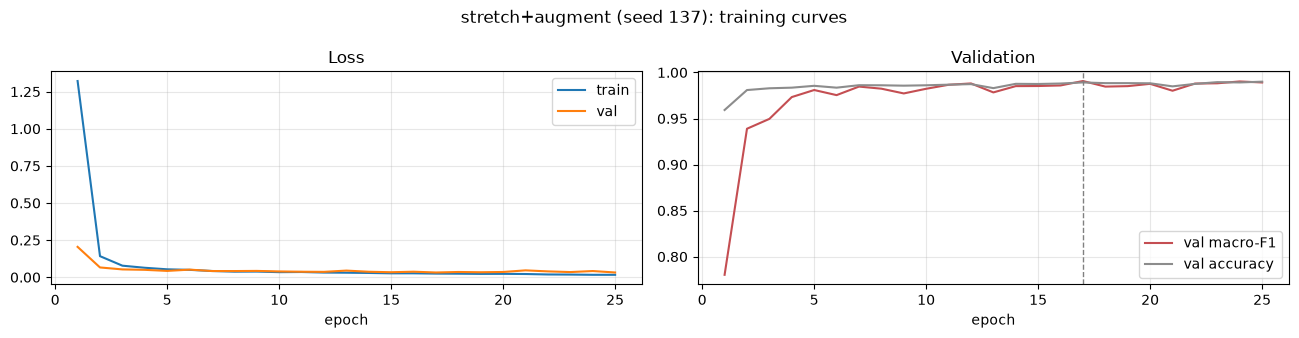

In [7]:
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
THAI_SM = font_manager.FontProperties(fname=str(FONT), size=12)


def save(fig, name):
    # write the figure for the report, then show it here
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()


def label(i):
    return f"{ch.character[i]} ({ch.folder[i]})"


FOCUS = os.environ.get("FOCUS", board.index[0])
seed_runs = cur[cur.experiment == FOCUS].sort_values("val_macro_f1", ascending=False)
run_dir = RUNS / seed_runs.run_id.iloc[0]
m = json.loads((run_dir / "metrics.json").read_text())
hist = pd.read_csv(run_dir / "history.csv")
pc = pd.read_csv(run_dir / "per_class.csv", keep_default_na=False, na_values=[""])
cm = np.load(run_dir / "confusion.npy")
preds = pd.read_csv(run_dir / "val_predictions.csv")
ch = classes.set_index("class_idx")

print(f"selected : {FOCUS}  run {m['run_id']}  seed {m['seed']}  split {m['split_id']}")
print(f"  experiment val macro-F1        : {board.macro_f1[FOCUS]:.4f} ± {board.macro_f1_sd[FOCUS]:.4f} over {len(seed_runs)} seeds")
print(f"  val macro-F1 (validated classes) : {m['val_macro_f1']:.4f}")
print(f"  val macro-F1 (all with val)      : {m['val_macro_f1_all']:.4f}")
print(f"  val accuracy                     : {m['val_acc']:.4f}")
print(f"  best epoch {m['best_epoch']} of {m['epochs_run']} run, {m['train_time_s']:.0f}s, {m['n_params']:,} params")
display(seed_runs[["run_id", "seed", "val_macro_f1", "val_acc", "best_epoch"]].round(4))

(FIG_DIR / "selected_model.json").write_text(json.dumps(dict(
    experiment=FOCUS, run_id=m["run_id"], seed=m["seed"], split_id=m["split_id"],
    train_version=resolve_config({})["train_version"],
    experiment_macro_f1_mean=float(board.macro_f1[FOCUS]), experiment_macro_f1_sd=float(board.macro_f1_sd[FOCUS]),
    val_macro_f1=m["val_macro_f1"], val_macro_f1_all=m["val_macro_f1_all"], val_acc=m["val_acc"],
    best_epoch=m["best_epoch"],
), indent=2) + "\n")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].plot(hist.epoch, hist.train_loss, label="train")
ax[0].plot(hist.epoch, hist.val_loss, label="val")
ax[0].set(title="Loss", xlabel="epoch")
ax[0].legend()
ax[1].plot(hist.epoch, hist.val_macro_f1, color="#C44E52", label="val macro-F1")
ax[1].plot(hist.epoch, hist.val_acc, color="#8C8C8C", label="val accuracy")
ax[1].axvline(m["best_epoch"], ls="--", c="gray", lw=1)
ax[1].set(title="Validation", xlabel="epoch")
ax[1].legend()
for a in ax:
    a.grid(alpha=0.3)
fig.suptitle(f"{FOCUS} (seed {m['seed']}): training curves")
plt.tight_layout()
save(fig, "training_curves")

### 6.1 · Per-class F1 and the worst classes

**Per-class F1**, weakest first. Grey bars are *weak* classes (fewer than 5 val images); their F1 is
close to noise. Not-validated classes have no val images and are absent.

**Worst classes** zooms in on the bottom of that chart. Precision and recall are drawn separately
because they fail differently: low recall means the class's own images go elsewhere, low precision
means other classes' images land on it. The note on the right names where most of the class's
missed images went.

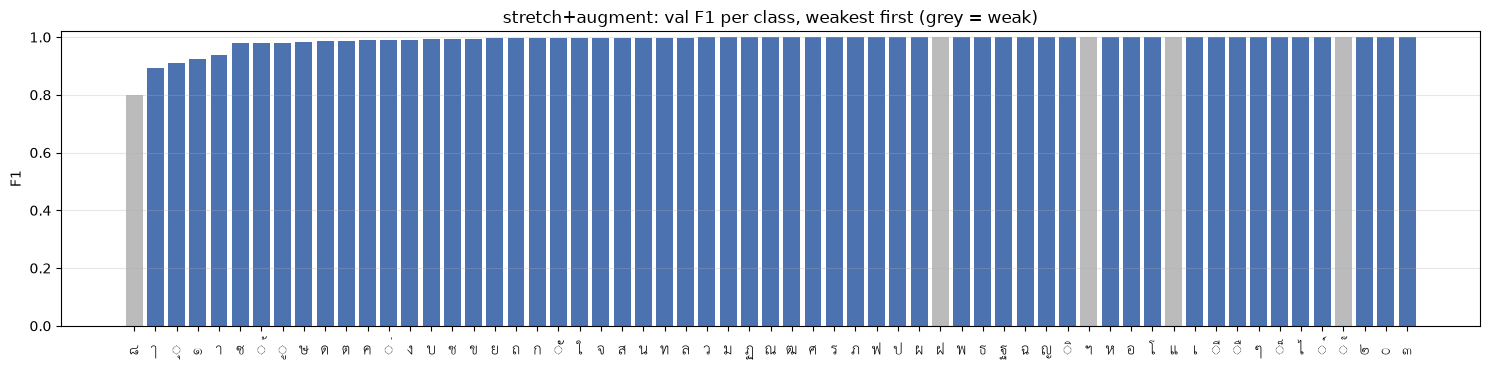

In [8]:
shown = pc[pc.support > 0].sort_values("f1")
fig, ax = plt.subplots(figsize=(15, 3.8))
ax.bar(range(len(shown)), shown.f1, color=np.where(shown.status == "weak", "#BBBBBB", "#4C72B0"))
ax.set_xticks(range(len(shown)))
ax.set_xticklabels(shown.character, fontproperties=THAI)
ax.set(title=f"{FOCUS}: val F1 per class, weakest first (grey = weak)", ylabel="F1", ylim=(0, 1.02))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save(fig, "per_class_f1")

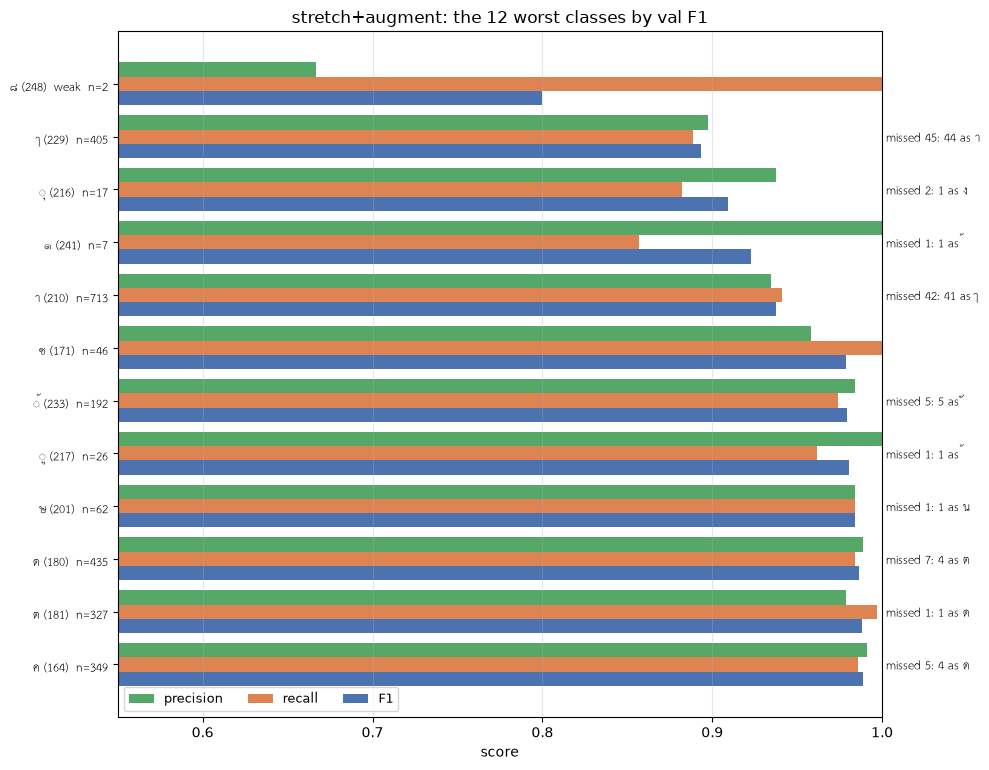

,class_idx,folder,character,status,train_n,support,precision,recall,f1
70,70,248,๘,weak,24,2,0.667,1.000,0.800
55,55,229,ๅ,validated,1069,405,0.898,0.889,0.893
48,48,216,ุ,validated,137,17,0.938,0.882,0.909
63,63,241,๑,validated,39,7,1.000,0.857,0.923
43,43,210,า,validated,3067,713,0.935,0.941,0.938
8,8,171,ซ,validated,224,46,0.958,1.000,0.979
59,59,233,้,validated,836,192,0.984,0.974,0.979
49,49,217,ู,validated,116,26,1.000,0.962,0.980
35,35,201,ษ,validated,203,62,0.984,0.984,0.984
15,15,180,ด,validated,1572,435,0.988,0.984,0.986


In [9]:
N_WORST = 12
worst = shown.head(N_WORST).iloc[::-1]  # worst at the top of a horizontal chart
y = np.arange(len(worst))
h = 0.27
fig, ax = plt.subplots(figsize=(10, 0.55 * len(worst) + 1.2))
for k, (col, colour) in enumerate([("precision", "#55A868"), ("recall", "#DD8452"), ("f1", "#4C72B0")]):
    ax.barh(y + (1 - k) * h, worst[col], h, color=colour, label=col if col != "f1" else "F1")
ax.set_yticks(y)
ax.set_yticklabels([f"{label(i)}{'  weak' if s == 'weak' else ''}  n={n}"
                    for i, s, n in zip(worst.class_idx, worst.status, worst.support, strict=True)], fontproperties=THAI_SM)
x0 = max(0.0, np.floor(worst[["precision", "recall", "f1"]].min().min() * 10) / 10 - 0.05)
ax.set_xlim(x0, 1.0)
for yi, i in zip(y, worst.class_idx, strict=True):
    row = cm[i].copy()
    row[i] = 0
    if row.sum():
        j = int(row.argmax())
        ax.text(1.005, yi, f"missed {row.sum()}: {row[j]} as {ch.character[j]}", va="center",
                fontproperties=THAI_SM, transform=ax.get_yaxis_transform())
ax.set(title=f"{FOCUS}: the {N_WORST} worst classes by val F1", xlabel="score")
ax.legend(loc="lower left", ncol=3, fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save(fig, "worst_classes")

shown.head(N_WORST)[["class_idx", "folder", "character", "status", "train_n", "support", "precision", "recall", "f1"]].round(3)

### 6.2 · Confusion matrix

**Full matrix**: rows are true classes, columns predictions, each row normalised to the share of
that class's val images. The colour scale is logarithmic, so a single stray image still shows
against a 99% diagonal; blank cells are exact zeros. Rows of not-validated classes are empty.

**Zoom**: only the classes that take part in the most frequent confusions, with raw counts written
in. A pair confused in both directions is either genuinely similar glyphs or a labelling problem,
and only looking at the images says which.

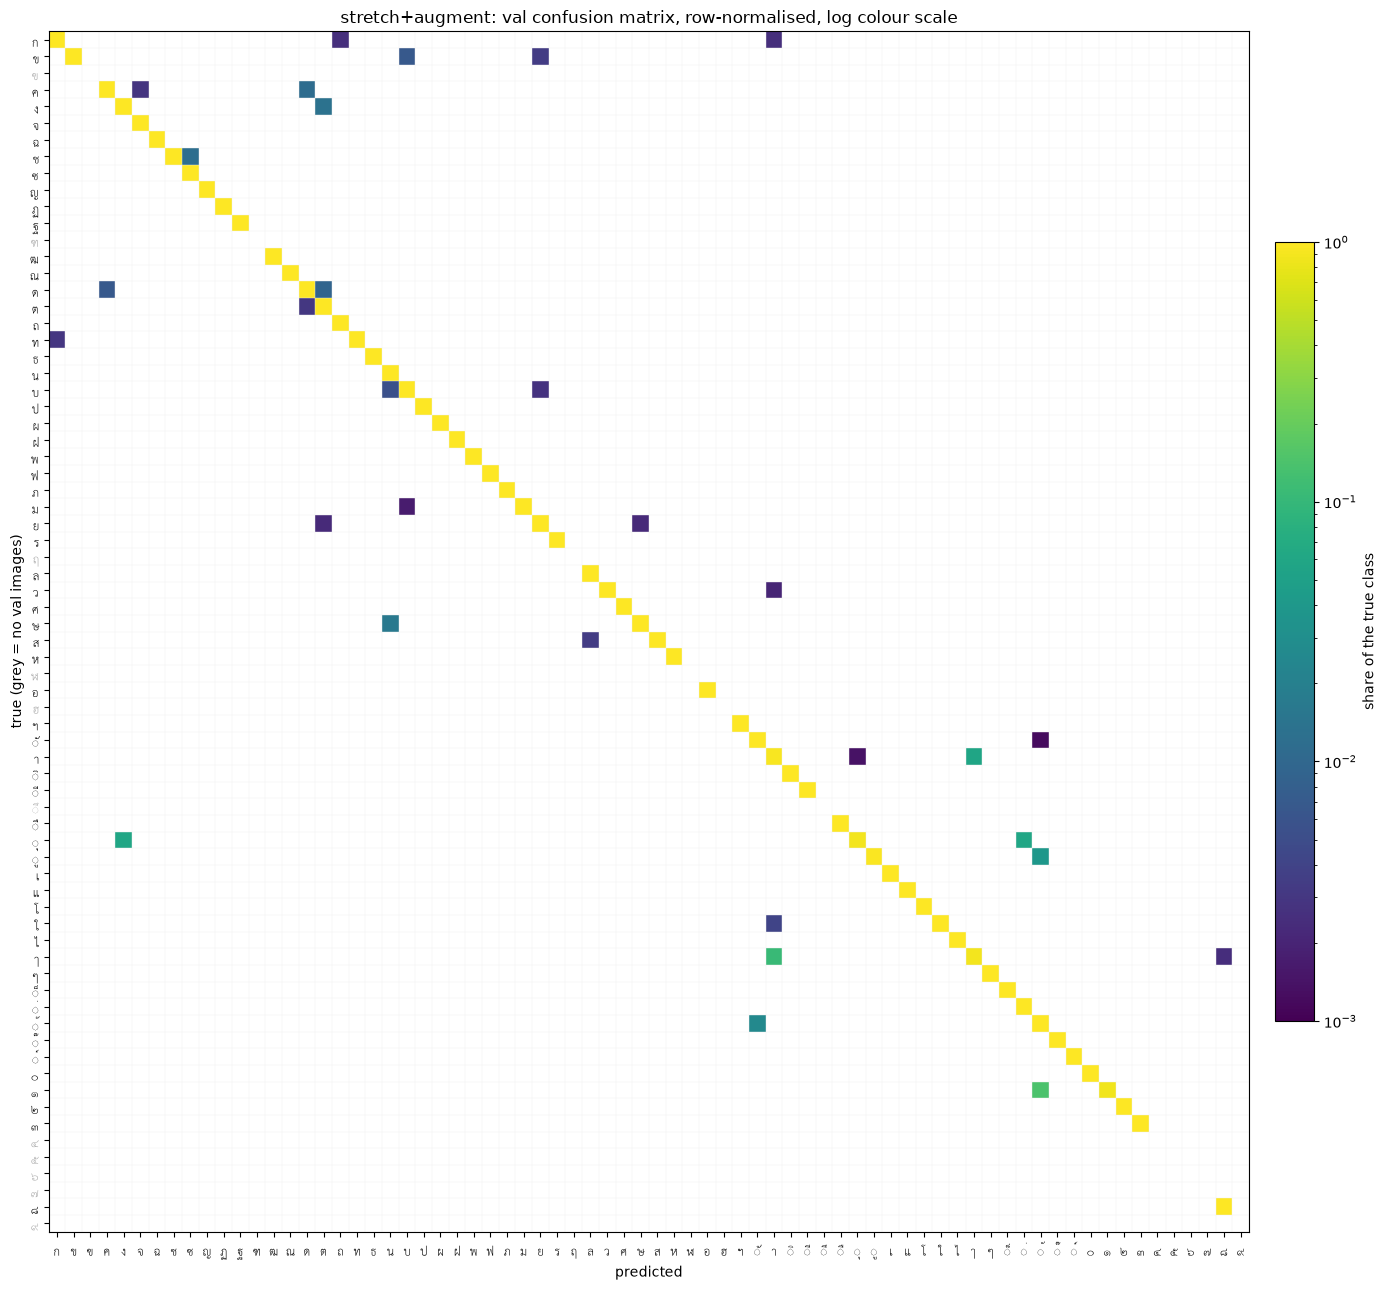

In [10]:
n = len(cm)
with np.errstate(divide="ignore", invalid="ignore"):
    cm_norm = np.where(cm.sum(1, keepdims=True) > 0, cm / cm.sum(1, keepdims=True), 0.0)
fig, ax = plt.subplots(figsize=(14, 13))
im = ax.imshow(np.ma.masked_equal(cm_norm, 0), cmap="viridis", norm=LogNorm(vmin=1e-3, vmax=1))
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(ch.character, fontproperties=THAI_SM)
ax.set_yticklabels(ch.character, fontproperties=THAI_SM)
no_val = cm.sum(1) == 0
for t in ax.get_yticklabels():
    if no_val[int(round(t.get_position()[1]))]:
        t.set_color("#AAAAAA")
ax.set_xticks(np.arange(n + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(n + 1) - 0.5, minor=True)
ax.grid(which="minor", color="#EEEEEE", lw=0.3)
ax.tick_params(which="minor", length=0)
ax.set(xlabel="predicted", ylabel="true (grey = no val images)",
       title=f"{FOCUS}: val confusion matrix, row-normalised, log colour scale")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="share of the true class")
plt.tight_layout()
save(fig, "confusion_matrix")

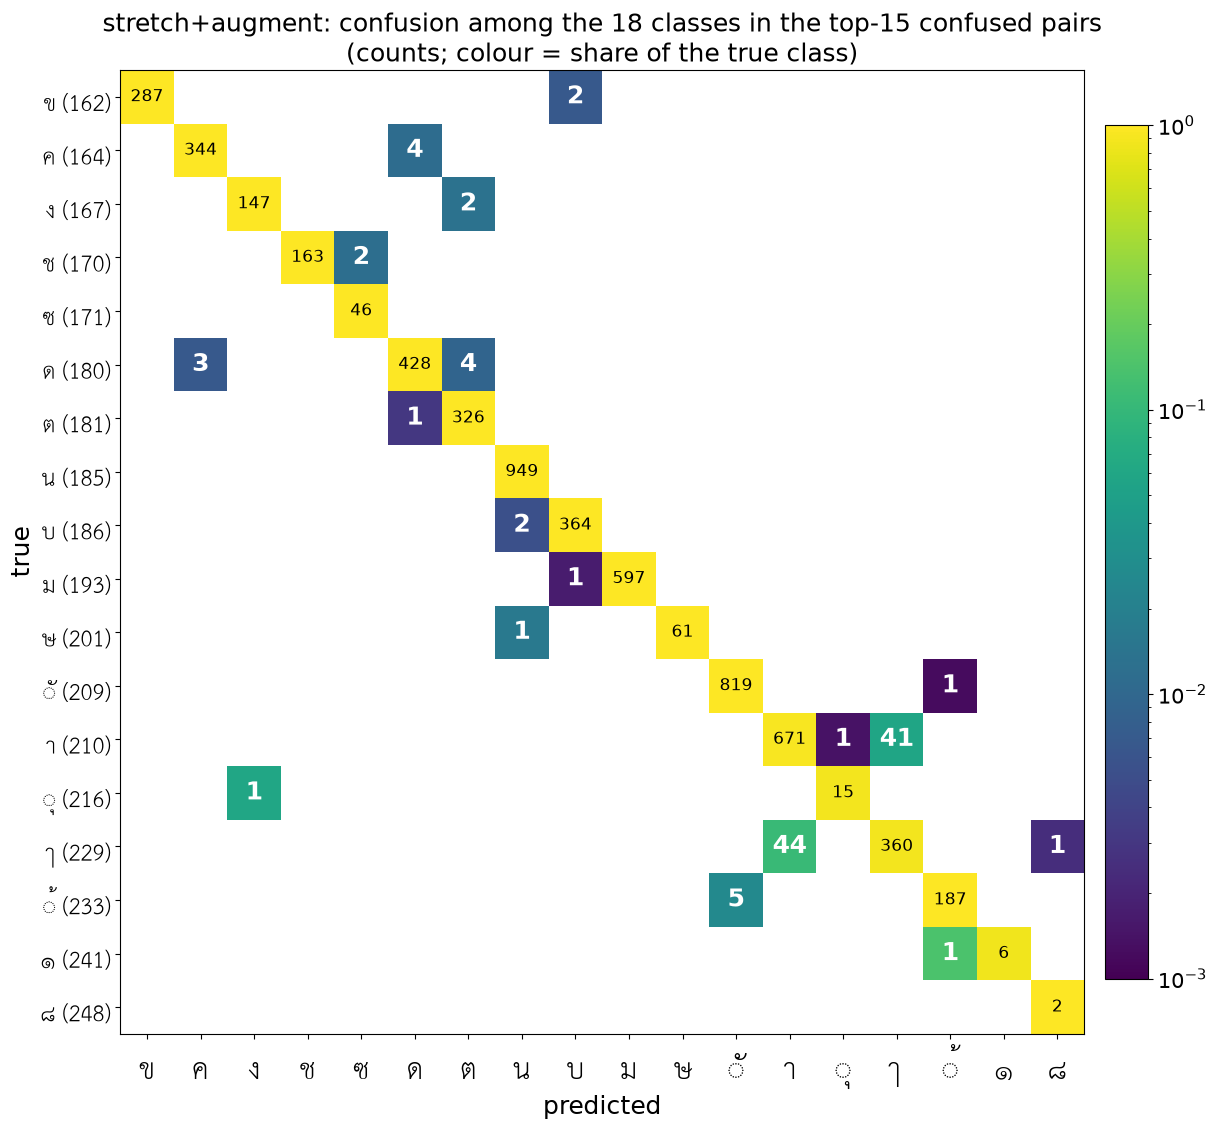

,true,predicted,count,share_of_true,reverse_count
0,ๅ (229),า (210),44,0.109,41
1,า (210),ๅ (229),41,0.058,44
2,้ (233),ั (209),5,0.026,1
3,ด (180),ต (181),4,0.009,1
4,ค (164),ด (180),4,0.011,3
5,ด (180),ค (164),3,0.007,4
6,บ (186),น (185),2,0.005,0
7,ง (167),ต (181),2,0.013,0
8,ข (162),บ (186),2,0.007,0
9,ช (170),ซ (171),2,0.012,0


In [11]:
tc = top_confused(cm, 15)
tc["true"] = tc.true_idx.map(label)
tc["predicted"] = tc.pred_idx.map(label)
tc["reverse_count"] = [int(cm[p, t]) for t, p in zip(tc.true_idx, tc.pred_idx, strict=True)]

sub = sorted(set(tc.true_idx) | set(tc.pred_idx))
cz, nz = cm[np.ix_(sub, sub)], cm_norm[np.ix_(sub, sub)]
THAI_LG = font_manager.FontProperties(fname=str(FONT), size=30)
THAI_MD = font_manager.FontProperties(fname=str(FONT), size=24)
fig, ax = plt.subplots(figsize=(0.55 * len(sub) + 2.5, 0.55 * len(sub) + 1.5))
im = ax.imshow(np.ma.masked_equal(nz, 0), cmap="viridis", norm=LogNorm(vmin=1e-3, vmax=1))
for r in range(len(sub)):
    for c in range(len(sub)):
        if cz[r, c]:
            ax.text(c, r, cz[r, c], ha="center", va="center", fontsize=12 if r == c else 18,
                    color="white" if nz[r, c] < 0.3 else "black", fontweight="normal" if r == c else "bold")
ax.set_xticks(range(len(sub)))
ax.set_yticks(range(len(sub)))
ax.set_xticklabels([ch.character[i] for i in sub], fontproperties=THAI_LG)
ax.set_yticklabels([label(i) for i in sub], fontproperties=THAI_MD)
ax.set_xlabel("predicted", fontsize=18)
ax.set_ylabel("true", fontsize=18)
ax.set_title(f"{FOCUS}: confusion among the {len(sub)} classes in the top-15 confused pairs\n(counts; colour = share of the true class)",
             fontsize=18)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02).ax.tick_params(labelsize=15)
plt.tight_layout()
save(fig, "confusion_zoom")

tc[["true", "predicted", "count", "share_of_true", "reverse_count"]].round(3)

### 6.3 · Wrongly confident

A mistake made at 55% confidence can be caught by a threshold or a second look; a mistake made at
99% cannot. The left panel compares the confidence of right and wrong predictions. The middle and
right panels count each class's mistakes, split at `CONF`: by the true class (whose images get
misread) and by the predicted class (which class the model wrongly claims). Confident mistakes are
also where label errors tend to hide, so the gallery shows the most confident ones for inspection.

val errors: 130 of 11,996; 21 of them at confidence ≥ 0.9


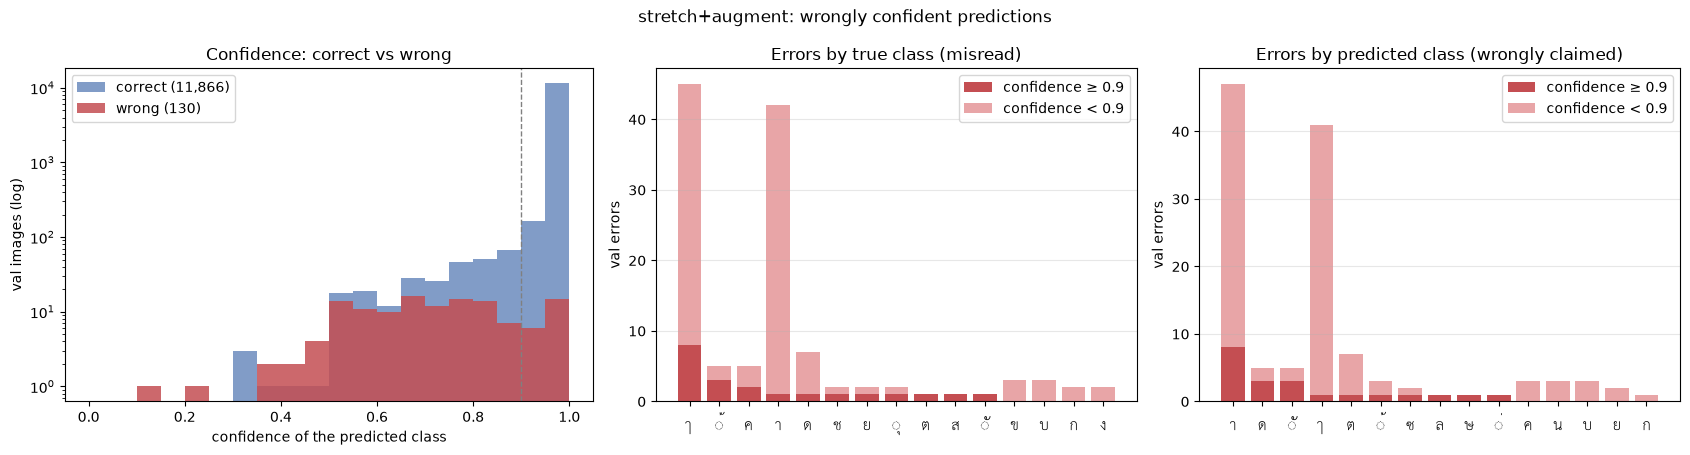

In [12]:
CONF = 0.9
N_TOP = 15
wrong = preds[preds.true_idx != preds.pred_idx]
right = preds[preds.true_idx == preds.pred_idx]
print(f"val errors: {len(wrong):,} of {len(preds):,}; {int((wrong.p_pred >= CONF).sum())} of them at confidence ≥ {CONF}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6), gridspec_kw=dict(width_ratios=[1.1, 1, 1]))
bins = np.linspace(0, 1, 21)
ax[0].hist(right.p_pred, bins, color="#4C72B0", alpha=0.7, label=f"correct ({len(right):,})")
ax[0].hist(wrong.p_pred, bins, color="#C44E52", alpha=0.85, label=f"wrong ({len(wrong):,})")
ax[0].axvline(CONF, ls="--", c="gray", lw=1)
ax[0].set(yscale="log", xlabel="confidence of the predicted class", ylabel="val images (log)",
          title="Confidence: correct vs wrong")
ax[0].legend(loc="upper left")
for a, key, what in [(ax[1], "true_idx", "true class (misread)"), (ax[2], "pred_idx", "predicted class (wrongly claimed)")]:
    g = (wrong.assign(confident=wrong.p_pred >= CONF).groupby(key).confident
         .agg(confident="sum", total="size").assign(unsure=lambda d: d.total - d.confident)
         .sort_values(["confident", "total"], ascending=False).head(N_TOP))
    x = np.arange(len(g))
    a.bar(x, g.confident, color="#C44E52", label=f"confidence ≥ {CONF}")
    a.bar(x, g.unsure, bottom=g.confident, color="#E8A5A7", label=f"confidence < {CONF}")
    a.set_xticks(x)
    a.set_xticklabels([ch.character[i] for i in g.index], fontproperties=THAI)
    a.set(title=f"Errors by {what}", ylabel="val errors")
    a.grid(axis="y", alpha=0.3)
    a.legend()
fig.suptitle(f"{FOCUS}: wrongly confident predictions")
plt.tight_layout()
save(fig, "wrongly_confident")

the 32 most confident of 130 val errors (true as predicted, confidence):


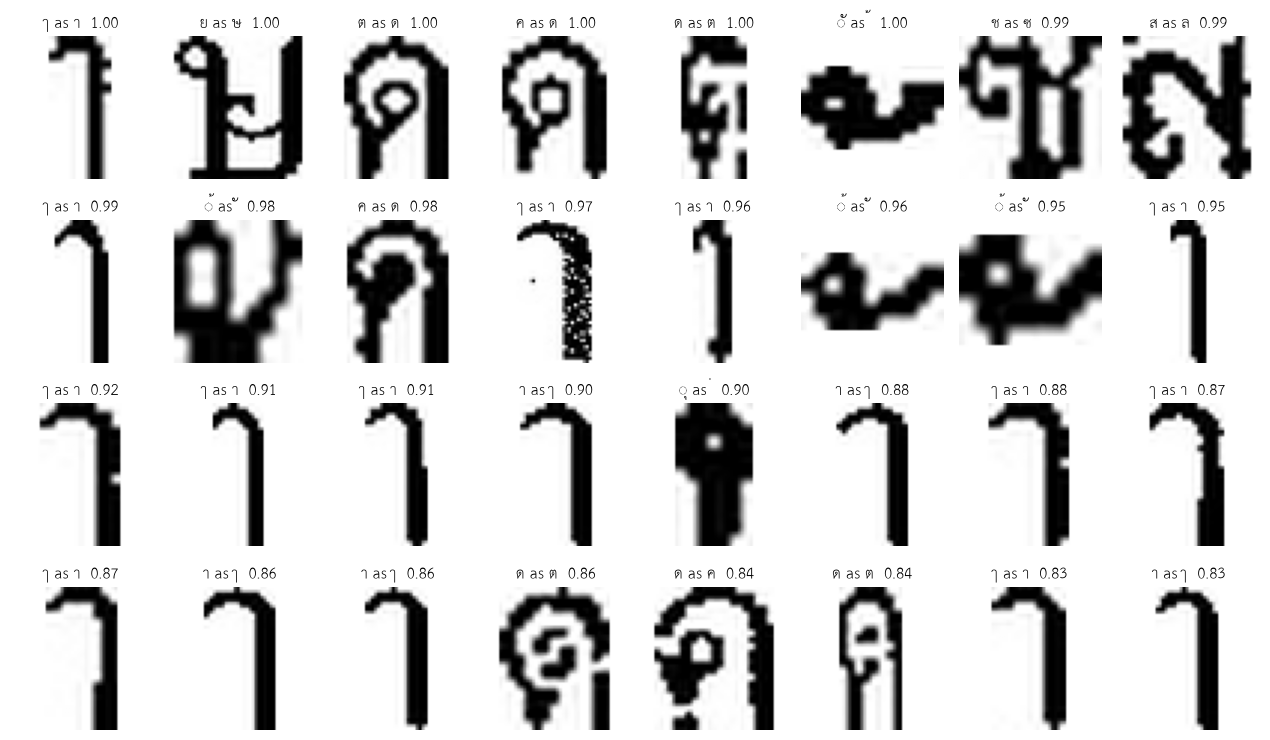

,path,writer_id,true,pred,p_pred,p_true
10332,210/be_018sg_6_36.jpg,be_018,229,210,0.9997,0.0002
5835,194/be_018tg_7_188.jpg,be_018,194,201,0.9997,0.0000
2332,181/be_002sg_9_37.jpg,be_002,181,180,0.9990,0.0010
1994,180/be_006sg_3_439.jpg,be_006,164,180,0.9987,0.0000
1891,180/bc_020sg_3_84.jpg,bc_020,180,181,0.9975,0.0006
11632,233/bc_009sg_1_17.jpg,bc_009,209,233,0.9969,0.0015
1642,171/be_006sg_6_17.jpg,be_006,170,171,0.9938,0.0057
7646,202/bc_020tg_3_176.jpg,bc_020,202,197,0.9894,0.0018
10276,210/be_016tg_9_345.jpg,be_016,229,210,0.9890,0.0110
8949,209/be_002tg_10_162.jpg,be_002,233,209,0.9779,0.0177


In [13]:
N_ERR = 32
err = wrong.sort_values("p_pred", ascending=False).head(N_ERR)
print(f"the {len(err)} most confident of {len(wrong):,} val errors (true as predicted, confidence):")
cols = 8
fig, ax = plt.subplots(int(np.ceil(len(err) / cols)), cols, figsize=(1.6 * cols, 1.9 * np.ceil(len(err) / cols)),
                       squeeze=False)
for a in ax.ravel():
    a.axis("off")
for a, r in zip(ax.ravel(), err.itertuples(), strict=False):
    with Image.open(RAW / r.path) as im:
        a.imshow(letterbox(im.convert("L"), 48), cmap="gray", vmin=0, vmax=255)
    a.set_title(f"{ch.character[r.true_idx]} as {ch.character[r.pred_idx]}  {r.p_pred:.2f}", fontproperties=THAI)
plt.tight_layout()
save(fig, "confident_errors")
err.assign(true=err.true_idx.map(ch.folder), pred=err.pred_idx.map(ch.folder))[
    ["path", "writer_id", "true", "pred", "p_pred", "p_true"]].head(12)

## 7 · Freeze for submission (`FREEZE=1`)

**What:** copy the best seed of each experiment in `FROZEN` from `runs/` to `models/<experiment>/`,
which is checked into git. `05_submit.ipynb` predicts the test set from there.

**Why:** `runs/` is gitignored and lives on this machine only. A run id also stops resolving from its
config as soon as `TRAIN_VERSION` or the split changes. The frozen copy is a byte-for-byte `model.pt`,
the class order it was trained with, and a `meta.json` (run id, seed, val metrics, sha256), so the
submission no longer depends on the cache.

`FROZEN` names the recommended model and its no-augmentation control. The ResNet-18 rows are left
out: at 43 MB a run they are too big to commit, and neither beats `stretch+augment`. `05_submit` can
still load any run on this machine by its id. The cell is off by default, so a rerun of this
notebook never rewrites the committed weights.


In [ ]:
FROZEN = ["stretch+augment", "stretch"]
if os.environ.get("FREEZE") != "1":
    print(f"skipped (set FREEZE=1 to copy {FROZEN} to models/)")
else:
    for name in FROZEN:
        best = cur[cur.experiment == name].sort_values("val_macro_f1", ascending=False).iloc[0]
        dest = freeze(RUNS / best.run_id, name)
        print(f"{name:18s} run {best.run_id}  seed {best.seed}  val macro-F1 {best.val_macro_f1:.4f} -> {dest.relative_to(ROOT)}")
for m in sorted(MODELS.glob("[!.]*/meta.json")):
    meta = json.loads(m.read_text())
    print(f"frozen: {m.parent.name:18s} run {meta['run_id']}  seed {meta['seed']}  frozen {meta['frozen_at']}")
